In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [7]:
class CustomerConcern(TypedDict):
    concern: str
    comments: str
    response: str

In [6]:
def  analyze_sentiment(state:CustomerConcern):
    return {"comments": f"{state['comments']}\nCustomer is furios"}

In [8]:
def marketing_response(state:CustomerConcern):
    return {"response": "We are extreemly sorry and our executive will reach out"}

In [9]:
marketing_graph_builder = StateGraph(CustomerConcern)
marketing_graph_builder.add_node("sentiment", analyze_sentiment)
marketing_graph_builder.add_node("response", marketing_response)
marketing_graph_builder.set_entry_point("sentiment")
marketing_graph_builder.add_edge("sentiment", "response")
marketing_graph_builder.set_finish_point("response")

In [12]:
def analyze_facts(state:CustomerConcern):
    return {"comments": f"{state['comments']}\nCustomer is genuine"}

In [10]:
def fin_response(state:CustomerConcern):
    return {"response": "Your money is safe with us"}

In [13]:
finance_graph_builder = StateGraph(CustomerConcern)
finance_graph_builder.add_node("facts", analyze_facts)
finance_graph_builder.add_node("fresponse", fin_response)
finance_graph_builder.set_entry_point("facts")
finance_graph_builder.add_edge("facts", "fresponse")
finance_graph_builder.set_finish_point("fresponse")

In [14]:
def init(state: CustomerConcern):
    return state

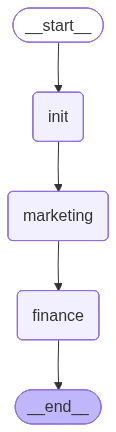

In [17]:
customer_care_graph = StateGraph(CustomerConcern)
marketing_graph = marketing_graph_builder.compile()
finance_graph = finance_graph_builder.compile()
customer_care_graph.add_node("init", init)
customer_care_graph.add_node("marketing", marketing_graph)
customer_care_graph.add_node("finance", finance_graph)
customer_care_graph.set_entry_point("init")
customer_care_graph.add_edge("init", "marketing")
customer_care_graph.add_edge("marketing", "finance")
customer_care_graph.set_finish_point("finance")
cc_graph = customer_care_graph.compile()
cc_graph

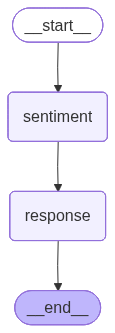

In [18]:
marketing_graph

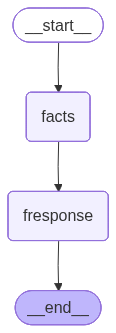

In [19]:
finance_graph

In [21]:
response = cc_graph.invoke({
    "concern": "Im sleepy",
    "comments": "",
    "response": ""
})

In [22]:
response

{'concern': 'Im sleepy',
 'comments': '\nCustomer is furios\nCustomer is genuine',
 'response': 'Your money is safe with us'}